$ \Large{\textbf{Powtórka Pythona 2}} $

$ \textbf{Zadanie 1 — konwerter temperatur} $

Napisz funkcję, która:

    -przyjmuje temperaturę w stopniach Celsjusza;
    -zwraca temperaturę w kelwinach;
    -dla temperatury poniżej -273.15°C zwraca None.

W głównej części programu pobierz temperaturę i odpowiednio obsłuż oba możliwe wyniki.

In [4]:
def celsius_to_kelvin(T_C):
    if T_C < -273.15:
        print("Podana temperatura jest niższa od zera absolutnego!")
        return None
    
    return T_C + 273.15

T = float(input("Podaj temperature w celcjuszach: "))

T_K = celsius_to_kelvin(T)

print(f"Temperatura w stopniach Kelwina wynosi: {T_K} K.")

Temperatura w stopniach Kelwina wynosi: 293.15 K.


$ \textbf{Zadanie 2 — ruch ciała} $

In [10]:
def calculate_motion(v_0, a, t):
    velocity = a*t + v_0 
    position = 0.5*a*(t**2) + v_0*t

    return velocity, position

v0 = 2.0 # m/s
a0 = 3.0 # m/s^2

times = [0, 1, 2, 3, 4, 5]
V = []
X = []

for t in times:
    v, x = calculate_motion(v0, a0, t)
    V.append(v)
    X.append(x)

print(f"{'Czas [s]':<16} | {'Prędkość [m/s]':<16} | {'Położenie [m]':<16}")
print("-" *52)

for x,y,z in zip(times, V, X):
    print(f"{x:<16} | {y:<16} | {z:<16}")

Czas [s]         | Prędkość [m/s]   | Położenie [m]   
----------------------------------------------------
0                | 2.0              | 0.0             
1                | 5.0              | 3.5             
2                | 8.0              | 10.0            
3                | 11.0             | 19.5            
4                | 14.0             | 32.0            
5                | 17.0             | 47.5            


$ \textbf{Zadanie 3 — energia mechaniczna} $

Napisz trzy funkcje. Program powinien:

    -pobrać masę, prędkość i wysokość;
    -nie zaakceptować ujemnej masy;
    -obliczyć wszystkie trzy energie;
    -wypisać wyniki;
    -wykonać obliczenia najpierw dla Ziemi, a następnie dla Księżyca, gdzie \(g=1{,}62\ \mathrm{m/s^2}\).

In [14]:
def k_energy(m, v):
    return 0.5*m*(v**2)

def p_energy(m, h, g=9.81):
    return m*g*h

def m_energy(m, v, h, g=9.81):
    return k_energy(m,v) + p_energy(m,h,g)


while True:
    mass = float(input("Podaj masę ciała w [kg]: "))
    velocity = float(input("Podaj prędkość ciała w [m/s]: "))
    height = float(input("Podaj wysokość na której znaduje się ciało w [m]: "))

    if mass <= 0 or velocity < 0 or height < 0:
        print("Podano nieprawidłowe wartości!")
        continue
    else:
        E_k = k_energy(mass, velocity)
        E_p1 = p_energy(mass, height)
        E_p2 = p_energy(mass, height, 1.62)
        E_m1 = m_energy(mass, velocity, height)
        E_m2 = m_energy(mass, velocity, height, 1.62)
        print("Dane dla Ziemii: ")
        print(f"Energia kinetyczna: {round(E_k, 5)}J")
        print(f"Energia potencjalna: {round(E_p1, 5)}J")
        print(f"Energia mechaniczna: {round(E_m1, 5)}J")
        print(" ")
        print("Dane dla Księżyca: ")
        print(f"Energia kinetyczna: {round(E_k, 5)}J")
        print(f"Energia potencjalna: {round(E_p2, 5)}J")
        print(f"Energia mechaniczna: {round(E_m2, 5)}J")
        break

Dane dla Ziemii: 
Energia kinetyczna: 100.0J
Energia potencjalna: 156.96J
Energia mechaniczna: 256.96J
 
Dane dla Księżyca: 
Energia kinetyczna: 100.0J
Energia potencjalna: 25.92J
Energia mechaniczna: 125.92J


$ \textbf{Zadanie 4 — numeryczna symulacja swobodnego spadku} $

Ciało zostaje puszczone z wysokości height z zerową prędkością początkową. Symulacja ma przebiegać małymi krokami czasu dt i ma działać do czasu aż ciało nie dotrze do ziemii. Funkcja powinna zwrócić jednocześnie:

    -czas spadania;
    -prędkość uderzenia;
    -liczbę wykonanych kroków symulacji.

In [25]:
import matplotlib.pyplot as plt
import math

Otrzymane wyniki nie są zgodne z rozwiązaniami analitycznymi
 
Ilość wykonanych kroków wynosi: 1428
 
Po 1.428 sekundach ciało uderzyło w ziemie
 
Prędkość uderzenia ciała wynosi: 14.00868
 
Czas spadania [s]     | Prędkość ciała [m/s]  | Wysokość ciała [m]   
-------------------------------------------------------------------
0.001                 | 0.00981               | 9.99999              
0.002                 | 0.01962               | 9.99997              
0.003                 | 0.02943               | 9.99994              
0.004                 | 0.03924               | 9.9999               
0.005                 | 0.04905               | 9.99985              
0.006                 | 0.05886               | 9.99979              
0.007                 | 0.06867               | 9.99973              
0.008                 | 0.07848               | 9.99965              
0.009                 | 0.08829               | 9.99956              
0.01                  | 0.0981           

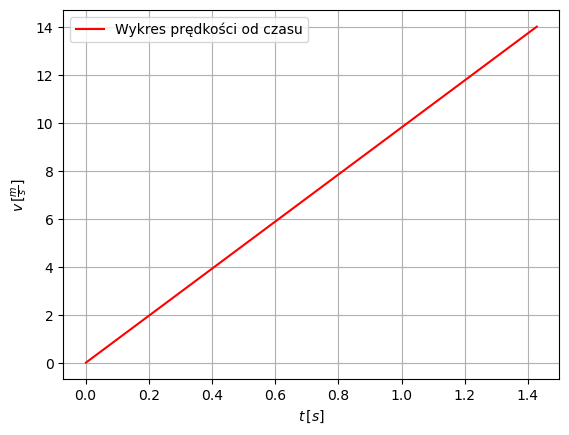

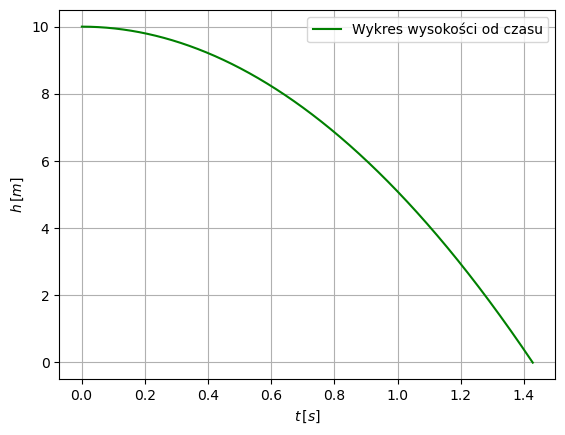

In [46]:
def simulate_fall(height, dt, g=9.81):
    h_new = height
    v_new = 0
    t_new = 0
    n = 0

    t_values = []
    v_values = []
    h_values = []

    while h_new > 0:
        if h_new <=0:
            h_new = None
        else:
            v_new = v_new + g*dt
            h_new = h_new - v_new*dt
            t_new += dt
            v_values.append(v_new)
            h_values.append(h_new)
            t_values.append(t_new)

            n += 1

    v_max = max(v_values)
    t_max = max(t_values)
    t_analitic = math.sqrt((2*height)/g)

    x = math.isclose(t_max, t_analitic)
    if x == True:
        print("Otrzymane wyniki są zgodne z rozwiązaniami analitycznymi")
    else:
        print("Otrzymane wyniki nie są zgodne z rozwiązaniami analitycznymi")

    print(" ")
    print(f'Ilość wykonanych kroków wynosi: {n}')
    print(" ")
    print(f'Po {round(t_max,5)} sekundach ciało uderzyło w ziemie')
    print(" ")
    print(f'Prędkość uderzenia ciała wynosi: {round(v_max,5)}')
    print(" ")

    print(f"{'Czas spadania [s]':<21} | {'Prędkość ciała [m/s]':<21} | {'Wysokość ciała [m]':<21}")
    print("-" *67)

    for t,v,h in zip(t_values, v_values, h_values):
        print(f"{round(t,5):<21} | {round(v,5):<21} | {round(h,5):<21}")

    plt.plot(t_values, v_values, color='red', label='Wykres prędkości od czasu')
    plt.xlabel(r"$t \, [s]$")
    plt.ylabel(r"$v \, [\frac{m}{s}]$")
    plt.legend()
    plt.grid(True)
    plt.show()


    plt.figure()
    plt.plot(t_values, h_values, color='green', label='Wykres wysokości od czasu')
    plt.xlabel(r"$t \, [s]$")
    plt.ylabel(r"$h \, [m]$")
    plt.legend()
    plt.grid(True)
    plt.show()

simulate_fall(10, 0.001)

$ \textbf{Zadanie 2 — poszukiwanie kąta rzutu} $

Dla każdego kąta oblicz:

$$ \mathrm{error}=|R(\alpha)-R_{\mathrm{target}}|. $$

Funkcja powinna zapamiętywać:

    -najlepszy dotychczas kąt;
    -odpowiadający mu zasięg;
    -najmniejszy dotychczas błąd.

Wymagania:

    -wykorzystaj projectile_range() wewnątrz find_best_angle();
    -dla v0 <= 0, target_range < 0 albo step <= 0 zwróć None;
    -wewnątrz funkcji nie używaj input() ani print();
    -obsłuż None w głównej części programu;

In [ ]:
def projectile_range(v_0, angle, g=9.81):
    alpha = math.radians(angle)
    R_alpha = ((v_0**2)*math.sin(2*alpha))/g
    return R_alpha

def find_best_angle(v_0, target_range, step=0.1, g=9.81):
    if v_0 <= 0 or target_range <0 or step <= 0:
        return None
    else:
        theta = []
        phi = 0.0

        while phi <= 90:
            theta.append(round(phi,5))
            phi += step

        R = []
        error = []

        for beta in theta:
            R_beta = projectile_range(v_0, beta)
            err = abs(R_beta-target_range)
            R.append(R_beta)
            error.append(err)

        #err_min = min(error)
        tolerance = 0.08

        BA = []
        BR = []
        BE = []

        for i in range(len(error)):
            #if error[i] == err_min:
            if error[i] < tolerance:
                best_angle = math.radians(theta[i])
                best_range = R[i]
                best_error = error[i]
                BA.append(best_angle)
                BR.append(best_range)
                BE.append(best_error)

        #return best_angle, best_range, best_error
        return BA, BR, BE

ba, br, be = find_best_angle(25, 40)

print(f'Najlepszy kąt w radianach: {ba}')
print(f'Odpowiadający mu zasięg: {br} m')
print(f'Najmniejszy błąd: {be} m')

Najlepszy kąt w radianach: [0.3385938748868999, 1.2322024519079966]
Odpowiadający mu zasięg: [39.92124180456552, 39.92124180456553] m
Najmniejszy błąd: [0.07875819543448159, 0.07875819543446738] m
